In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout

# Voor GPU support
#physical_devices = tf.config.experimental.list_physical_devices('GPU')
#tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [2]:
dataset_train = pd.read_csv('NSE-TATAGLOBAL.csv')
training_set = dataset_train.iloc[:, 1:2].values
dataset_train.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-09-28,234.05,235.95,230.20,233.50,233.75,3069914,7162.35
1,2018-09-27,234.55,236.80,231.10,233.80,233.25,5082859,11859.95
2,2018-09-26,240.00,240.00,232.50,235.00,234.25,2240909,5248.60
3,2018-09-25,233.30,236.75,232.00,236.25,236.10,2349368,5503.90
4,2018-09-24,233.55,239.20,230.75,234.00,233.30,3423509,7999.55


In [3]:
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)
print(training_set_scaled.shape)

(2035, 1)


In [4]:
X_train = []
y_train = []
for i in range(60, 2035):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print(X_train.shape)

(1975, 60, 1)


In [5]:
regressor = Sequential()

regressor.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

regressor.add(Dense(units = 1))

regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

regressor.fit(X_train, y_train, epochs = 100, batch_size = 8)

Epoch 1/100


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


247/247 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0143
Epoch 2/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0030
Epoch 3/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0024
Epoch 4/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0026
Epoch 5/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0021
Epoch 6/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0022
Epoch 7/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0020
Epoch 8/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0018
Epoch 9/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.0016
Epoch 10/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0013
Epoch 11/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0012
Epoch 12/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0012
Epoch 13/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0013
Epoch 14/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0013
Epoch 15/100
247/247 ━━━━━━━━━━━━━━━━━━━━

In [6]:
dataset_test = pd.read_csv('tatatest.csv')
real_stock_price = dataset_test.iloc[:, 1:2].values


dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis = 0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)
X_test = []
for i in range(60, 76):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step


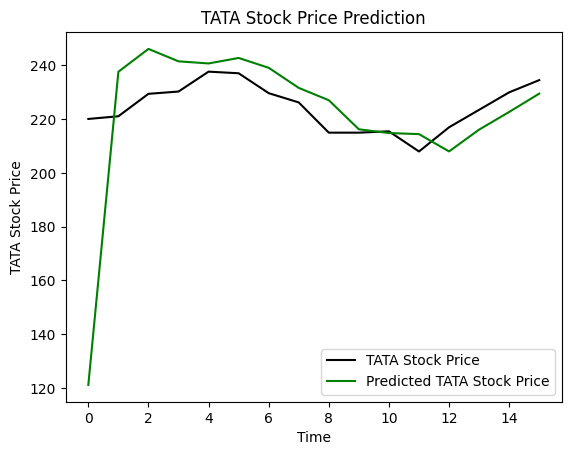

In [7]:
plt.plot(real_stock_price, color = 'black', label = 'TATA Stock Price')
plt.plot(predicted_stock_price, color = 'green', label = 'Predicted TATA Stock Price')
plt.title('TATA Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('TATA Stock Price')
plt.legend()
plt.show()